# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Kayne Hoy`
**SFU ID:** `301543404`
**Date:** `July 5th, 2026`

---

> Before you start: read the full assignment README on Canvas.
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.
> Every cell marked `# YOUR CODE HERE` must be completed.
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.

## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style. I kept this simple so the notebook stays close to the course examples.
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")

Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.

### Load the data

In [2]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)

Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [3]:
# Summary statistics
df_ab.describe(include='all').round(2)

,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U79488,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [4]:
# Missing values
df_ab.isnull().sum()

,0
user_id,0
ab_group,0
device_type,0
account_age_days,0
prior_whiteboard_sessions,0
plan_region,0
num_collaborators,0
feature_tour_completed,0
templates_used,0
ai_suggestions_used,0


### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution

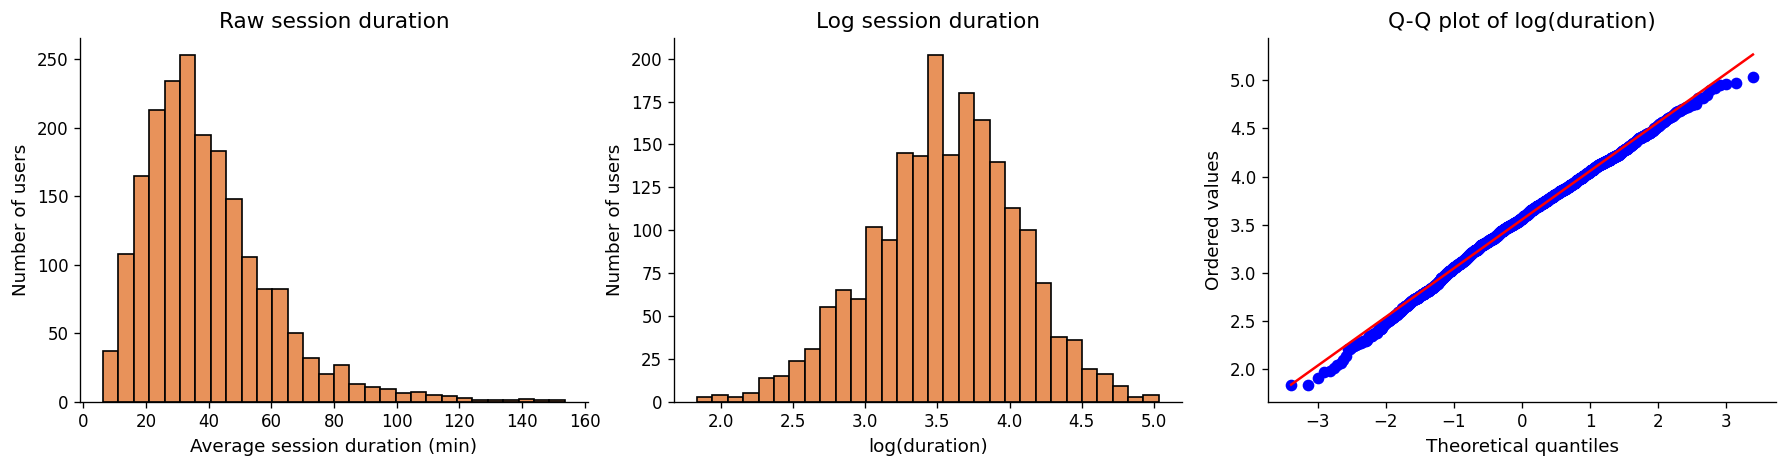

Raw skewness: 1.377
Log skewness: -0.213


In [5]:
# This cell checks the outcome distribution before modeling.
# I compare the raw outcome with the log-transformed outcome because the
# lecture showed that right-skewed variables can become easier to model after a log transform.

# Target outcome variable
outcome = 'avg_whiteboard_session_duration_min'
y_raw = df_ab[outcome]
df_ab['log_duration'] = np.log(df_ab[outcome])
y_log = df_ab['log_duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw outcome histogram
axes[0].hist(y_raw, bins=30, edgecolor='black', color=ACCENT)
axes[0].set_title('Raw session duration')
axes[0].set_xlabel('Average session duration (min)')
axes[0].set_ylabel('Number of users')

# Log outcome histogram
axes[1].hist(y_log, bins=30, edgecolor='black', color=ACCENT)
axes[1].set_title('Log session duration')
axes[1].set_xlabel('log(duration)')
axes[1].set_ylabel('Number of users')

# Q-Q plot for the log outcome
stats.probplot(y_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot of log(duration)')
axes[2].set_xlabel('Theoretical quantiles')
axes[2].set_ylabel('Ordered values')

plt.tight_layout()
plt.show()

print(f"Raw skewness: {y_raw.skew():.3f}")
print(f"Log skewness: {y_log.skew():.3f}")

**✏️ Your interpretation (A1.1):**

*Original prompt: Is the log-transformed outcome more normally distributed? How does the Q-Q plot support your conclusion? Will you use the raw or log outcome in your model?*

**My interpretation:**

The raw average session duration is not normally distributed because it is clearly right-skewed. Most users have shorter or moderate sessions, while a smaller group has very long sessions, so the right tail is pulled outward. The skewness value also supports this: the raw outcome has a skewness of about `1.38`, while the log-transformed outcome has a skewness of about `-0.21`, which is much closer to zero. The Q-Q plot for `log_duration` is not perfect, especially at the two tails, but the middle points follow the reference line much more closely than I would expect from the raw distribution. Because of this, I will use `log_duration` in the OLS model because it better fits the normal-error idea from the regression lecture and lets me interpret coefficients as approximate percentage changes.

#### A1.2 — Examine the confounders

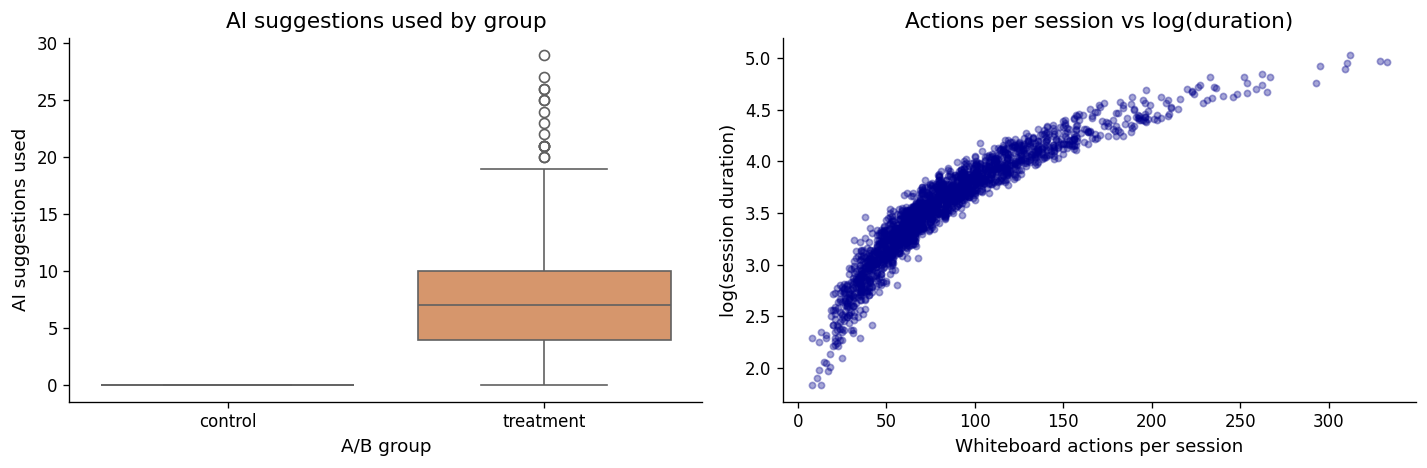

Correlation between whiteboard actions/session and log(duration): 0.914

AI suggestions used by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [6]:
# This cell focuses on two variables that are measured during the experiment window.
# They are important to inspect, but they are problematic as controls because they happen
# after treatment assignment and are very close to the outcome itself.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# AI suggestions are only available to the treatment group, so this variable partly encodes treatment itself.
sns.boxplot(data=df_ab, x='ab_group', y='ai_suggestions_used', ax=axes[0], color=ACCENT)
axes[0].set_title('AI suggestions used by group')
axes[0].set_xlabel('A/B group')
axes[0].set_ylabel('AI suggestions used')

# Actions per session is almost part of the same behavior as session duration.
axes[1].scatter(
    df_ab['whiteboard_actions_per_session'],
    df_ab['log_duration'],
    alpha=0.35,
    s=14,
    color='darkblue'
)
axes[1].set_title('Actions per session vs log(duration)')
axes[1].set_xlabel('Whiteboard actions per session')
axes[1].set_ylabel('log(session duration)')

plt.tight_layout()
plt.show()

corr_actions = df_ab['whiteboard_actions_per_session'].corr(df_ab['log_duration'])
print(f"Correlation between whiteboard actions/session and log(duration): {corr_actions:.3f}")
print("\nAI suggestions used by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))

**✏️ Your interpretation (A1.2):**

*Original prompt: What do you notice about `ai_suggestions_used` across the two groups? What does the correlation between `whiteboard_actions_per_session` and the outcome suggest? Why should neither be included in your model?*

**My interpretation:**

`ai_suggestions_used` is zero for the control group because those users did not have access to the AI assistant. This means it is not a clean baseline predictor; it is partly produced by the treatment itself. If I included it in the model, I would be controlling for something that only exists after treatment assignment, which would make the treatment coefficient harder to interpret. `whiteboard_actions_per_session` also should not be included because it is very close to the outcome: the correlation with `log_duration` is about `0.91`, and users who stay longer naturally have more time to make more actions. For that reason, I will exclude both variables from the main OLS model because they are post-treatment or outcome-adjacent variables, and including them could control away the effect I am trying to estimate.

#### A1.3 — Predictor distributions and relationships with outcome

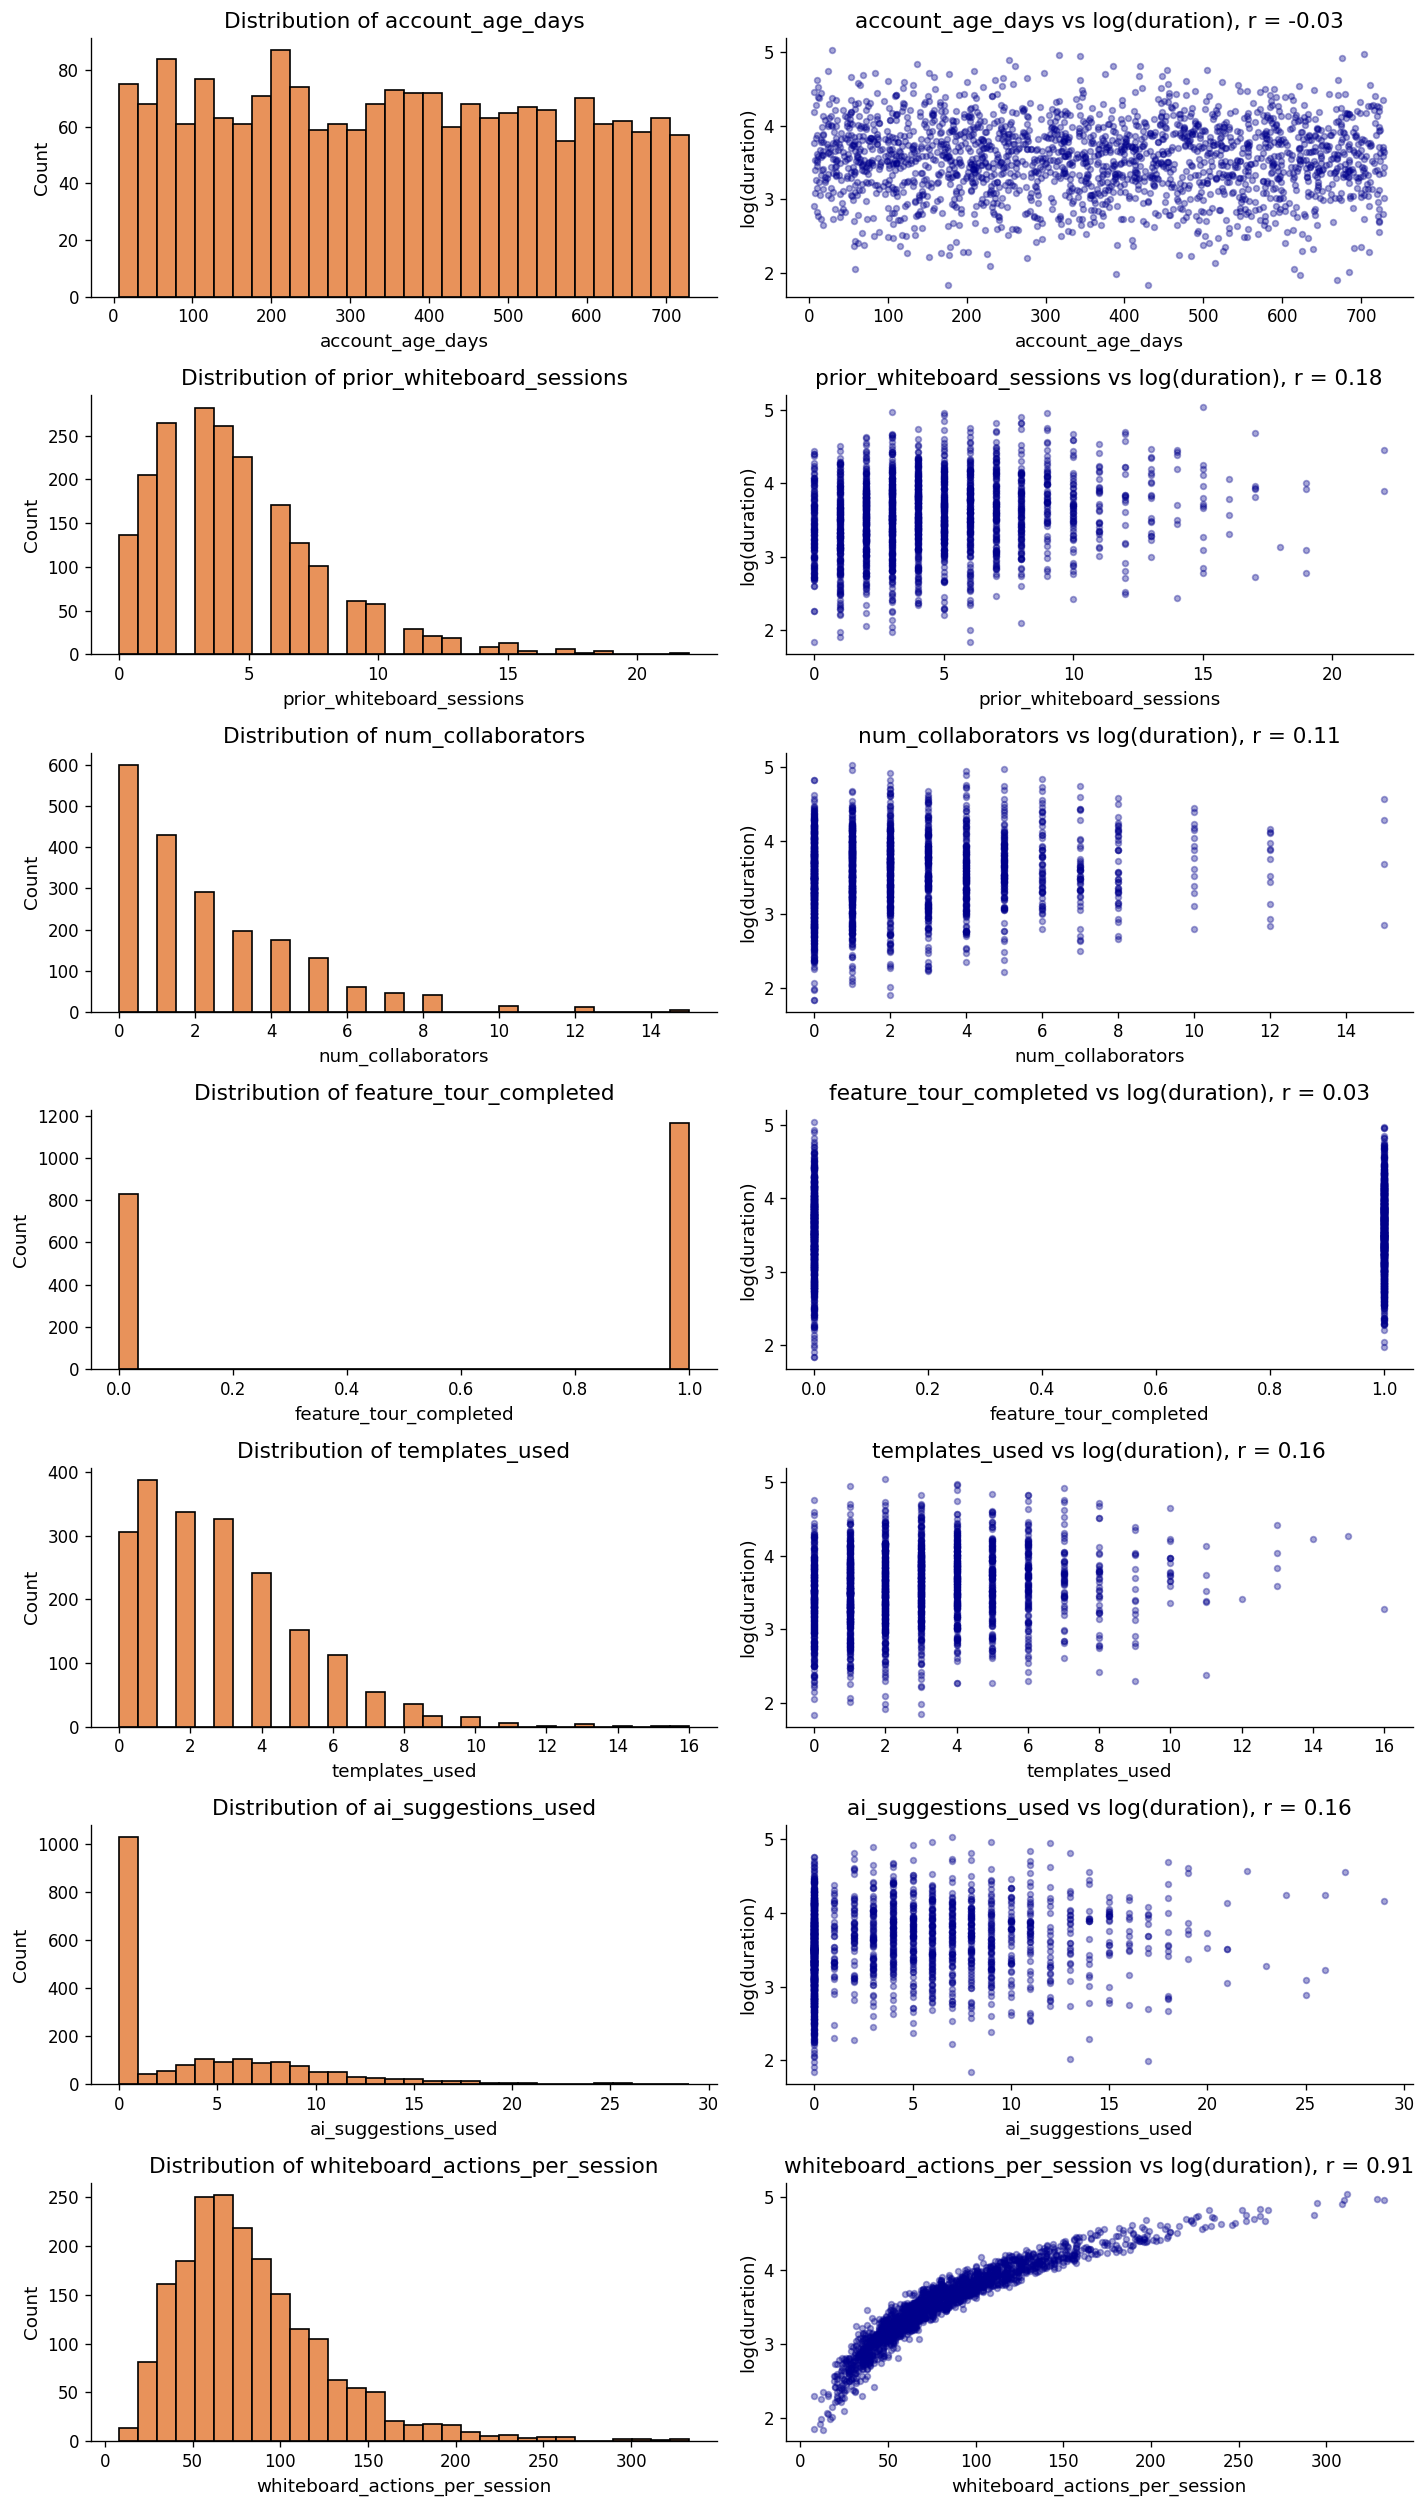

Skewness of numeric predictors:
num_collaborators                 1.550
ai_suggestions_used               1.439
whiteboard_actions_per_session    1.426
prior_whiteboard_sessions         1.202
templates_used                    1.164
account_age_days                  0.058
feature_tour_completed           -0.341
dtype: float64


In [7]:
# This cell checks each numeric predictor with two simple plots:
# 1. its own distribution
# 2. its relationship with log(session duration)

num_predictors = [
    'account_age_days',
    'prior_whiteboard_sessions',
    'num_collaborators',
    'feature_tour_completed',
    'templates_used',
    'ai_suggestions_used',
    'whiteboard_actions_per_session'
]

fig, axes = plt.subplots(len(num_predictors), 2, figsize=(12, 3 * len(num_predictors)))

for i, col in enumerate(num_predictors):
    # Distribution of the predictor
    axes[i, 0].hist(df_ab[col], bins=30, edgecolor='black', color=ACCENT)
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Relationship with the log-transformed outcome
    axes[i, 1].scatter(df_ab[col], df_ab['log_duration'], alpha=0.35, s=12, color='darkblue')
    corr = df_ab[col].corr(df_ab['log_duration'])
    axes[i, 1].set_title(f'{col} vs log(duration), r = {corr:.2f}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('log(duration)')

plt.tight_layout()
plt.show()

print('Skewness of numeric predictors:')
print(df_ab[num_predictors].skew().sort_values(ascending=False).round(3))

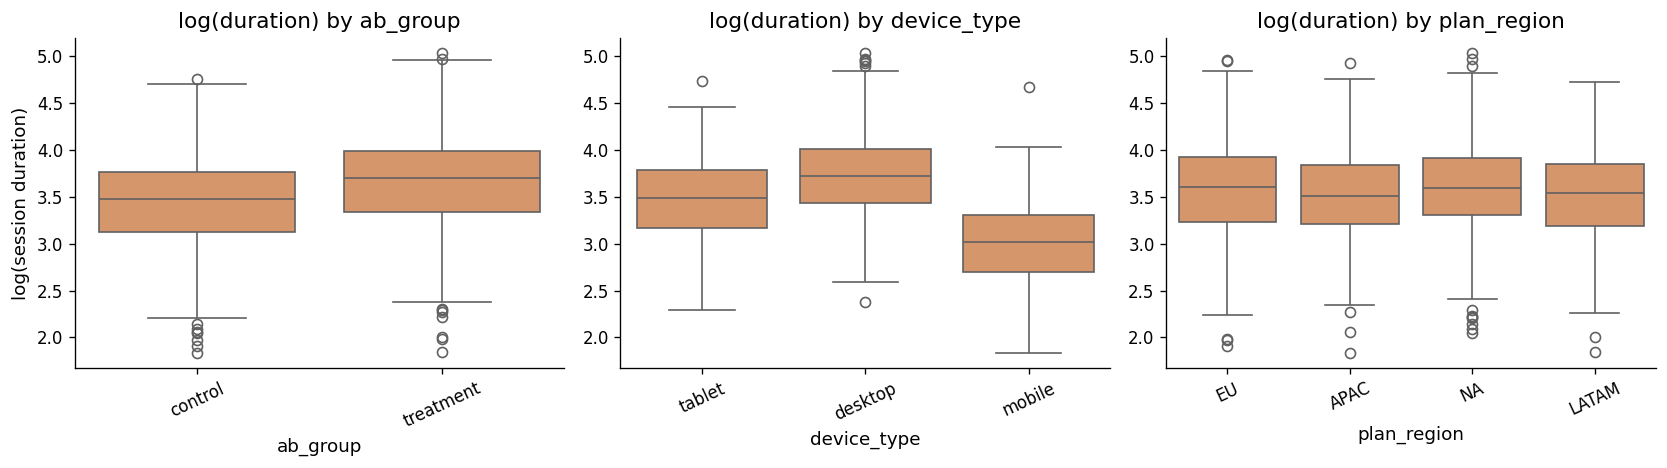

In [8]:
# This cell compares log session duration across the categorical predictors.
# These boxplots help me see whether the groups have different central tendencies.

cat_predictors = ['ab_group', 'device_type', 'plan_region']

fig, axes = plt.subplots(1, len(cat_predictors), figsize=(14, 4))

for i, col in enumerate(cat_predictors):
    sns.boxplot(data=df_ab, x=col, y='log_duration', ax=axes[i], color=ACCENT)
    axes[i].set_title(f'log(duration) by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(session duration)' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*

**My interpretation:**

The EDA suggests that the treatment group has longer average whiteboard sessions than the control group, so `ab_group` is the main explanatory variable I want to test in the OLS model. `prior_whiteboard_sessions` and `num_collaborators` also look promising because they are pre-treatment user/account variables and both have positive relationships with `log_duration`. Several count-like predictors are right-skewed, especially `num_collaborators` and `prior_whiteboard_sessions`, so I will use `log1p()` to reduce the influence of extreme high values while still keeping users with zero values. I will exclude `ai_suggestions_used` and `whiteboard_actions_per_session` because they are measured during the experiment and are not clean baseline controls. I will also exclude `templates_used` from the main treatment-effect model because it is measured during the experiment window, so it may be part of the behavior caused by the treatment rather than a fair control variable.

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.

In [9]:
#     Load baseline dataset

#     // 1. Encode Categorical Variables
#     Convert experimental group ('ab_group') into a binary integer indicator
#     Generate dummy indicators (one-hot encoding) for device types, omitting the first category
#     Generate dummy indicators (one-hot encoding) for regions, omitting the first category

#     // 2. Perform Optional Transformations
#     Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

#     // 3. Assemble Modeling Dataset
#     Merge numerical characteristics, binary groups, and dummy indicators into matrix X
#     Set target vector y as the log-transformed outcome variable

#     // 4. Quality Control
#     Verify that there are no missing (null) values in feature matrix X
#     Inspect matrix dimensions and print a preview of the processed data

In [10]:
# I build the OLS feature matrix using variables that are available before or at assignment.
# I avoid post-treatment variables so the treatment coefficient is easier to interpret.

# Treatment dummy: 0 = control, 1 = treatment
ab_dummy = (df_ab['ab_group'] == 'treatment').astype(int).rename('ab_group')

# Binary onboarding feature
feature_tour = df_ab['feature_tour_completed'].astype(int)

# Log-transform skewed count variables using log1p so zero values are handled safely.
log_account_age = np.log1p(df_ab['account_age_days']).rename('log_account_age_days')
log_prior_sessions = np.log1p(df_ab['prior_whiteboard_sessions']).rename('log_prior_whiteboard_sessions')
log_collaborators = np.log1p(df_ab['num_collaborators']).rename('log_num_collaborators')

# One-hot encode categorical variables and drop one level to avoid the dummy variable trap.
device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device_type', drop_first=True, dtype=int)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='plan_region', drop_first=True, dtype=int)

# Final feature matrix for OLS
X = pd.concat([
    ab_dummy,
    feature_tour,
    log_account_age,
    log_prior_sessions,
    log_collaborators,
    device_dummies,
    region_dummies
], axis=1).astype(float)

# Target is the log-transformed outcome from A1.
y = df_ab['log_duration']

# Quality checks
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Infinite values in X: {np.isinf(X.to_numpy()).sum()}")
print("\nFinal feature columns:")
print(list(X.columns))

X.head(3)

Feature matrix shape: (2000, 10)
Missing values in X: 0
Infinite values in X: 0

Final feature columns:
['ab_group', 'feature_tour_completed', 'log_account_age_days', 'log_prior_whiteboard_sessions', 'log_num_collaborators', 'device_type_mobile', 'device_type_tablet', 'plan_region_EU', 'plan_region_LATAM', 'plan_region_NA']


,ab_group,feature_tour_completed,log_account_age_days,log_prior_whiteboard_sessions,log_num_collaborators,device_type_mobile,device_type_tablet,plan_region_EU,plan_region_LATAM,plan_region_NA
0,0.0,1.0,6.171701,1.609438,1.386294,0.0,1.0,1.0,0.0,0.0
1,0.0,0.0,6.452049,2.302585,0.693147,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,5.075174,2.397895,1.791759,0.0,0.0,0.0,0.0,1.0


**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*

**My interpretation:**

My final OLS feature set is `ab_group`, `feature_tour_completed`, `log_account_age_days`, `log_prior_whiteboard_sessions`, `log_num_collaborators`, the device dummy variables, and the region dummy variables. I included `ab_group` because it is the experimental treatment variable, so it directly answers the question of whether AI assistant access changed session duration. I included `feature_tour_completed` because onboarding may affect how comfortable users are with the whiteboard tool and may explain some variation in session length. I log-transformed `account_age_days`, `prior_whiteboard_sessions`, and `num_collaborators` because these variables are count-like or skewed, and the feature engineering lecture showed that log transforms can reduce the dominance of very large values. I included device and region as one-hot encoded control variables because usage patterns may differ by device and geographic region, and I dropped one category from each set of dummies to avoid the dummy variable trap. I also checked the final feature matrix and confirmed that it has no missing or infinite values before fitting the model.

### A3 — OLS Regression

In [11]:
# Add a constant for the intercept, then fit the OLS regression model.
# This follows the lecture idea of using regression as an explanatory model.

X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:           log_duration   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     111.9
Date:                Mon, 06 Jul 2026   Prob (F-statistic):          1.31e-184
Time:                        03:15:34   Log-Likelihood:                -1025.2
No. Observations:                2000   AIC:                             2072.
Df Residuals:                    1989   BIC:                             2134.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

#### A3.1 — Interpret the model

In [12]:
# This cell extracts the main model statistics and translates log coefficients
# into more understandable percentage changes.

print(f"R-squared:          {model_ols.rsquared:.4f}")
print(f"Adjusted R-squared: {model_ols.rsquared_adj:.4f}")
print()

ab_coef = model_ols.params['ab_group']
ab_pval = model_ols.pvalues['ab_group']
ab_pct_change = np.exp(ab_coef) - 1
control_typical_duration = np.exp(df_ab.loc[df_ab['ab_group'] == 'control', 'log_duration'].mean())
ab_min_effect = control_typical_duration * ab_pct_change

print('Treatment effect:')
print(f"ab_group coefficient: {ab_coef:.4f}")
print(f"p-value:              {ab_pval:.4g}")
print(f"Approx. % change:     {ab_pct_change:.1%}")
print(f"Approx. minute change for a typical control user: {ab_min_effect:.2f} minutes")
print()

# Table of coefficients, p-values, and approximate percentage changes.
coef_table = pd.DataFrame({
    'coef_log_scale': model_ols.params,
    'p_value': model_ols.pvalues,
    'approx_percent_change': np.exp(model_ols.params) - 1
}).sort_values('p_value')

print('Coefficient table:')
display(coef_table.round(4))

print('Predictors significant at alpha = 0.05:')
sig = coef_table[(coef_table['p_value'] < 0.05) & (coef_table.index != 'const')]
display(sig.round(4))

R-squared:          0.3600
Adjusted R-squared: 0.3567

Treatment effect:
ab_group coefficient: 0.2164
p-value:              1.043e-31
Approx. % change:     24.2%
Approx. minute change for a typical control user: 7.55 minutes

Coefficient table:


,coef_log_scale,p_value,approx_percent_change
const,3.3431,0.0000,27.3064
device_type_mobile,-0.7274,0.0000,-0.5168
device_type_tablet,-0.2585,0.0000,-0.2278
ab_group,0.2164,0.0000,0.2415
log_prior_whiteboard_sessions,0.1420,0.0000,0.1526
log_num_collaborators,0.0866,0.0000,0.0905
plan_region_NA,0.0804,0.0008,0.0837
plan_region_EU,0.0752,0.0022,0.0781
feature_tour_completed,0.0495,0.0072,0.0508
log_account_age_days,-0.0171,0.0887,-0.0170


Predictors significant at alpha = 0.05:


,coef_log_scale,p_value,approx_percent_change
device_type_mobile,-0.7274,0.0000,-0.5168
device_type_tablet,-0.2585,0.0000,-0.2278
ab_group,0.2164,0.0000,0.2415
log_prior_whiteboard_sessions,0.1420,0.0000,0.1526
log_num_collaborators,0.0866,0.0000,0.0905
plan_region_NA,0.0804,0.0008,0.0837
plan_region_EU,0.0752,0.0022,0.0781
feature_tour_completed,0.0495,0.0072,0.0508


**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*

**My results paragraph:**

I fitted an OLS regression model predicting `log_duration` from treatment assignment and baseline user characteristics. The model had an R² of about `0.360`, meaning it explained about 36% of the variation in log average session duration. This is a meaningful amount of explained variation for user-behavior data, but it also shows that many individual differences are still not captured by the model. The treatment coefficient for `ab_group` was positive and statistically significant (`coef = 0.216`, `p < 0.001`), which means users with AI assistant access had about `24.2%` longer sessions than control users, holding the other variables constant. For a typical control user, this is about a `7.6` minute increase, so I would treat the AI assistant effect as practically meaningful and not only statistically significant. Other notable predictors were device type and prior use: mobile users and tablet users had shorter sessions than desktop users, while users with more prior whiteboard sessions and more collaborators tended to have longer sessions. This result makes logical sense because desktop use may support longer design work, and users with more prior activity or collaborators may already have stronger reasons to spend time in the product.

#### A3.2 — Regression diagnostics

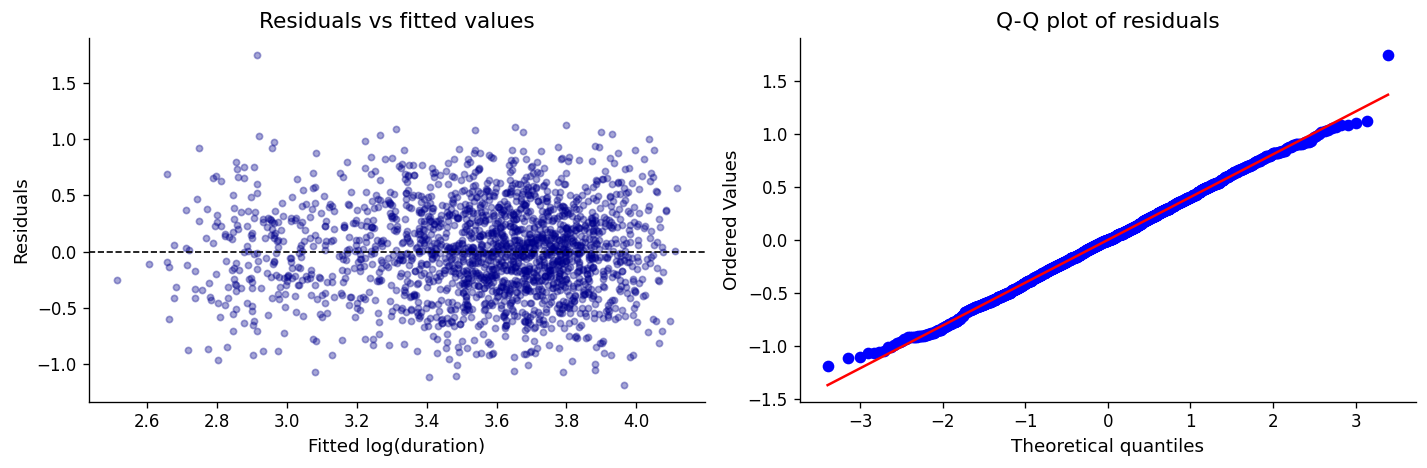

Residual mean: 0.0000
Residual skewness: 0.0279


In [14]:
# Regression diagnostics from the lecture: check residual patterns and residual normality.

fitted = model_ols.fittedvalues
residuals = model_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted checks whether residual spread changes across predicted values.
axes[0].scatter(fitted, residuals, alpha=0.35, s=14, color='darkblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs fitted values')
axes[0].set_xlabel('Fitted log(duration)')
axes[0].set_ylabel('Residuals')

# Q-Q plot checks whether errors are approximately normal.
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot of residuals')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual skewness: {residuals.skew():.4f}")

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*

**My interpretation:**

The residuals are mostly scattered around zero, so I do not see a strong curved pattern that would make the linear model clearly inappropriate. The spread is not perfectly equal across all fitted values, which means the homoscedasticity assumption is not perfect, but the pattern is still reasonable for this assignment after using the log-transformed outcome. The Q-Q plot shows that the middle of the residual distribution follows the normal reference line fairly well. The main concern is at the tails, where the points move away from the line, meaning a few users still have residuals that are larger or smaller than the model expects under a perfect normal distribution. Overall, I would not claim the assumptions are perfectly satisfied, but the diagnostics support using the OLS model as a useful explanatory model.

### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.

**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*

**My hypothesis before fitting the model:**

I will test the interaction between `ab_group` and `log_prior_whiteboard_sessions`. My hypothesis is that the AI assistant may help newer or less experienced users more because they have less prior knowledge of how to use the whiteboard tool efficiently. In other words, I expect the treatment effect to be stronger for users with fewer prior whiteboard sessions and weaker for users who were already active before the experiment. This is theoretically motivated because the AI assistant may act like guidance or support, and guidance should matter more when users do not already know the tool well. This hypothesis also connects to the lecture idea that an average treatment effect can hide different effects across subgroups.

In [15]:
# Create an interaction between treatment assignment and prior whiteboard experience.

X_interact = X.copy()
X_interact['ab_x_log_prior_whiteboard_sessions'] = (
    X_interact['ab_group'] * X_interact['log_prior_whiteboard_sessions']
)

X_interact_const = sm.add_constant(X_interact)
model_interact = sm.OLS(y, X_interact_const).fit()
print(model_interact.summary())

interaction_terms = pd.DataFrame({
    'coef': model_interact.params,
    'p_value': model_interact.pvalues,
    'approx_percent_change': np.exp(model_interact.params) - 1
}).loc[['ab_group', 'log_prior_whiteboard_sessions', 'ab_x_log_prior_whiteboard_sessions']]

print('\nKey interaction terms:')
display(interaction_terms.round(4))

                            OLS Regression Results                            
Dep. Variable:           log_duration   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     102.0
Date:                Mon, 06 Jul 2026   Prob (F-statistic):          3.64e-184
Time:                        03:15:34   Log-Likelihood:                -1023.8
No. Observations:                2000   AIC:                             2072.
Df Residuals:                    1988   BIC:                             2139.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

,coef,p_value,approx_percent_change
ab_group,0.1471,0.0013,0.1585
log_prior_whiteboard_sessions,0.1194,0.0000,0.1268
ab_x_log_prior_whiteboard_sessions,0.0457,0.0975,0.0468


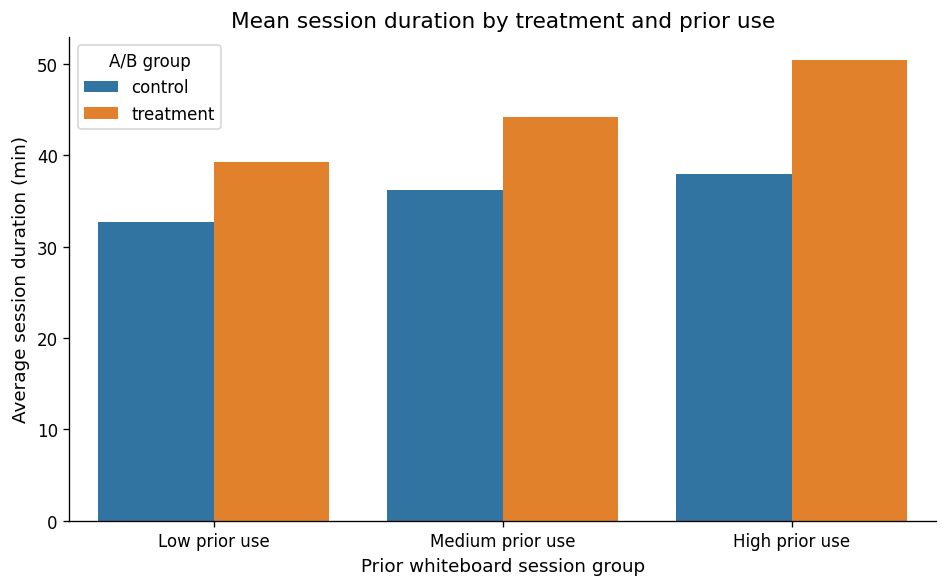

,prior_session_group,ab_group,avg_whiteboard_session_duration_min
0,Low prior use,control,32.681935
1,Low prior use,treatment,39.315618
2,Medium prior use,control,36.179009
3,Medium prior use,treatment,44.192039
4,High prior use,control,37.995235
5,High prior use,treatment,50.423934


In [16]:
# Visualize the interaction by grouping users into low, medium, and high prior-use groups.
# This makes the continuous interaction easier to read.

plot_df = df_ab.copy()
plot_df['prior_session_group'] = pd.qcut(
    plot_df['prior_whiteboard_sessions'],
    q=3,
    labels=['Low prior use', 'Medium prior use', 'High prior use']
)

mean_duration = (
    plot_df
    .groupby(['prior_session_group', 'ab_group'])['avg_whiteboard_session_duration_min']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=mean_duration,
    x='prior_session_group',
    y='avg_whiteboard_session_duration_min',
    hue='ab_group',
    ax=ax
)
ax.set_title('Mean session duration by treatment and prior use')
ax.set_xlabel('Prior whiteboard session group')
ax.set_ylabel('Average session duration (min)')
ax.legend(title='A/B group')
plt.tight_layout()
plt.show()

mean_duration

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*

**My interpretation:**

My hypothesis was not clearly supported. I predicted that the AI assistant would help newer users more, but the interaction coefficient was positive (`coef = 0.046`), which points in the opposite direction: the treatment effect may become slightly larger as prior whiteboard experience increases. However, the interaction p-value was about `0.098`, which is above the `0.05` significance threshold, so I would not make a strong claim that the treatment effect truly differs by prior use. The grouped bar chart still shows that treatment users generally have longer sessions across low, medium, and high prior-use groups. Based on this, the safest interpretation is that the AI assistant appears broadly useful, but this dataset does not give strong evidence that beginners or power users benefit more. For rollout, I would recommend making the feature available widely, while continuing to collect more data before using prior whiteboard experience as a targeting rule.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.

In [17]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)

Shape: (3000, 15)

Column types:
user_id                         object
signup_date                     object
first_session_date              object
device_type                     object
country_tier                    object
referral_source                 object
num_sessions_30d                 int64
total_time_min_30d               int64
projects_created_30d             int64
exports_30d                      int64
collaborators_invited_30d        int64
support_tickets_30d              int64
used_premium_feature_preview     int64
ai_assistant_sessions_30d        int64
subscribed                       int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [18]:
df_sub.describe(include='all').round(2)

,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.

In [19]:
# Feature engineering for the subscription dataset.
# These transformations follow the lecture ideas: dates need to become numeric features,
# categories need encoding, and ratios need safe handling.

# 1. Parse date columns
_df = df_sub.copy()
_df['signup_date'] = pd.to_datetime(_df['signup_date'])
_df['first_session_date'] = pd.to_datetime(_df['first_session_date'])

# Save back to df_sub so later EDA can use the engineered columns.
df_sub = _df

# 2. Days between signup and first session
# A smaller value means the user became active quickly after signup.
df_sub['days_to_first_session'] = (
    df_sub['first_session_date'] - df_sub['signup_date']
).dt.days

# 3. Average session duration.
# I explicitly handle the divide-by-zero edge case even though this dataset has no zero-session rows.
df_sub['avg_session_duration_min'] = np.where(
    df_sub['num_sessions_30d'] == 0,
    0,
    df_sub['total_time_min_30d'] / df_sub['num_sessions_30d']
)

# 4. Weekend signup indicator
# Monday=0, ..., Saturday=5, Sunday=6
df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.dayofweek.isin([5, 6]).astype(int)

# 5. Country tier is ordinal because tier_1, tier_2, and tier_3 have a natural ranking.
df_sub['country_tier_enc'] = df_sub['country_tier'].map({
    'tier_1': 1,
    'tier_2': 2,
    'tier_3': 3
})

# 6. One-hot encode unordered categories.
device_dummies_sub = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True, dtype=int)
referral_dummies_sub = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True, dtype=int)

# I use average session duration instead of total_time_min_30d in the model.
# total_time_min_30d is mechanically related to num_sessions_30d and avg_session_duration_min,
# so keeping all three would make the interpretation less clean.
raw_numeric = [
    'num_sessions_30d',
    'projects_created_30d',
    'exports_30d',
    'collaborators_invited_30d',
    'support_tickets_30d',
    'used_premium_feature_preview',
    'ai_assistant_sessions_30d'
]

engineered_features = [
    'days_to_first_session',
    'avg_session_duration_min',
    'is_weekend_signup',
    'country_tier_enc'
]

X_sub = pd.concat(
    [df_sub[raw_numeric + engineered_features], device_dummies_sub, referral_dummies_sub],
    axis=1
).astype(float)
y_sub = df_sub['subscribed'].astype(int)

# Quality checks
print(f"Zero-session users: {(df_sub['num_sessions_30d'] == 0).sum()}")
print(f"Any NaN values in X_sub: {X_sub.isna().any().any()}")
print(f"Any infinite values in X_sub: {np.isinf(X_sub.to_numpy()).any()}")
print(f"All features numeric: {all(X_sub.dtypes != 'object')}")
print(f"Feature matrix shape: {X_sub.shape}")
print('\nFeature names:')
print(list(X_sub.columns))

X_sub.head(3)

Zero-session users: 0
Any NaN values in X_sub: False
Any infinite values in X_sub: False
All features numeric: True
Feature matrix shape: (3000, 16)

Feature names:
['num_sessions_30d', 'projects_created_30d', 'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d', 'used_premium_feature_preview', 'ai_assistant_sessions_30d', 'days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup', 'country_tier_enc', 'device_mobile', 'device_tablet', 'ref_paid_ad', 'ref_referral', 'ref_social']


,num_sessions_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_enc,device_mobile,device_tablet,ref_paid_ad,ref_referral,ref_social
0,1.0,1.0,0.0,0.0,0.0,1.0,6.0,5.0,96.0000,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,15.0,8.0,1.0,5.0,0.0,0.0,0.0,0.0,17.8000,0.0,2.0,0.0,1.0,0.0,0.0,1.0
2,16.0,0.0,0.0,3.0,3.0,1.0,4.0,14.0,16.4375,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*

**My interpretation:**

`days_to_first_session` may predict subscription because users who start using the product soon after signup are likely more activated and more motivated. `avg_session_duration_min` may predict subscription because longer average sessions suggest deeper engagement, not just repeated short visits. `is_weekend_signup` may matter because weekend users might have different work habits, personal-project goals, or urgency compared with weekday users. I encoded `country_tier` as an ordinal variable because the tiers have a natural market order, and moving from tier 1 to tier 3 may reflect differences in pricing, payment access, or market maturity. I one-hot encoded `device_type` and `referral_source` because they are unordered categories, so assigning them values like 1, 2, and 3 would create a fake ranking that the model could misread. I kept behavioral count features such as sessions, projects, exports, collaborators, support tickets, premium preview, and AI assistant sessions because they describe how actively the user used Phigma during the first 30 days. For the divide-by-zero edge case, I used `np.where()` so that users with zero sessions would receive an average session duration of `0` instead of producing an infinite or missing value; this dataset had no zero-session users, but the code still handles the case safely.

### B2 — EDA for Subscription

In [20]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")

Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


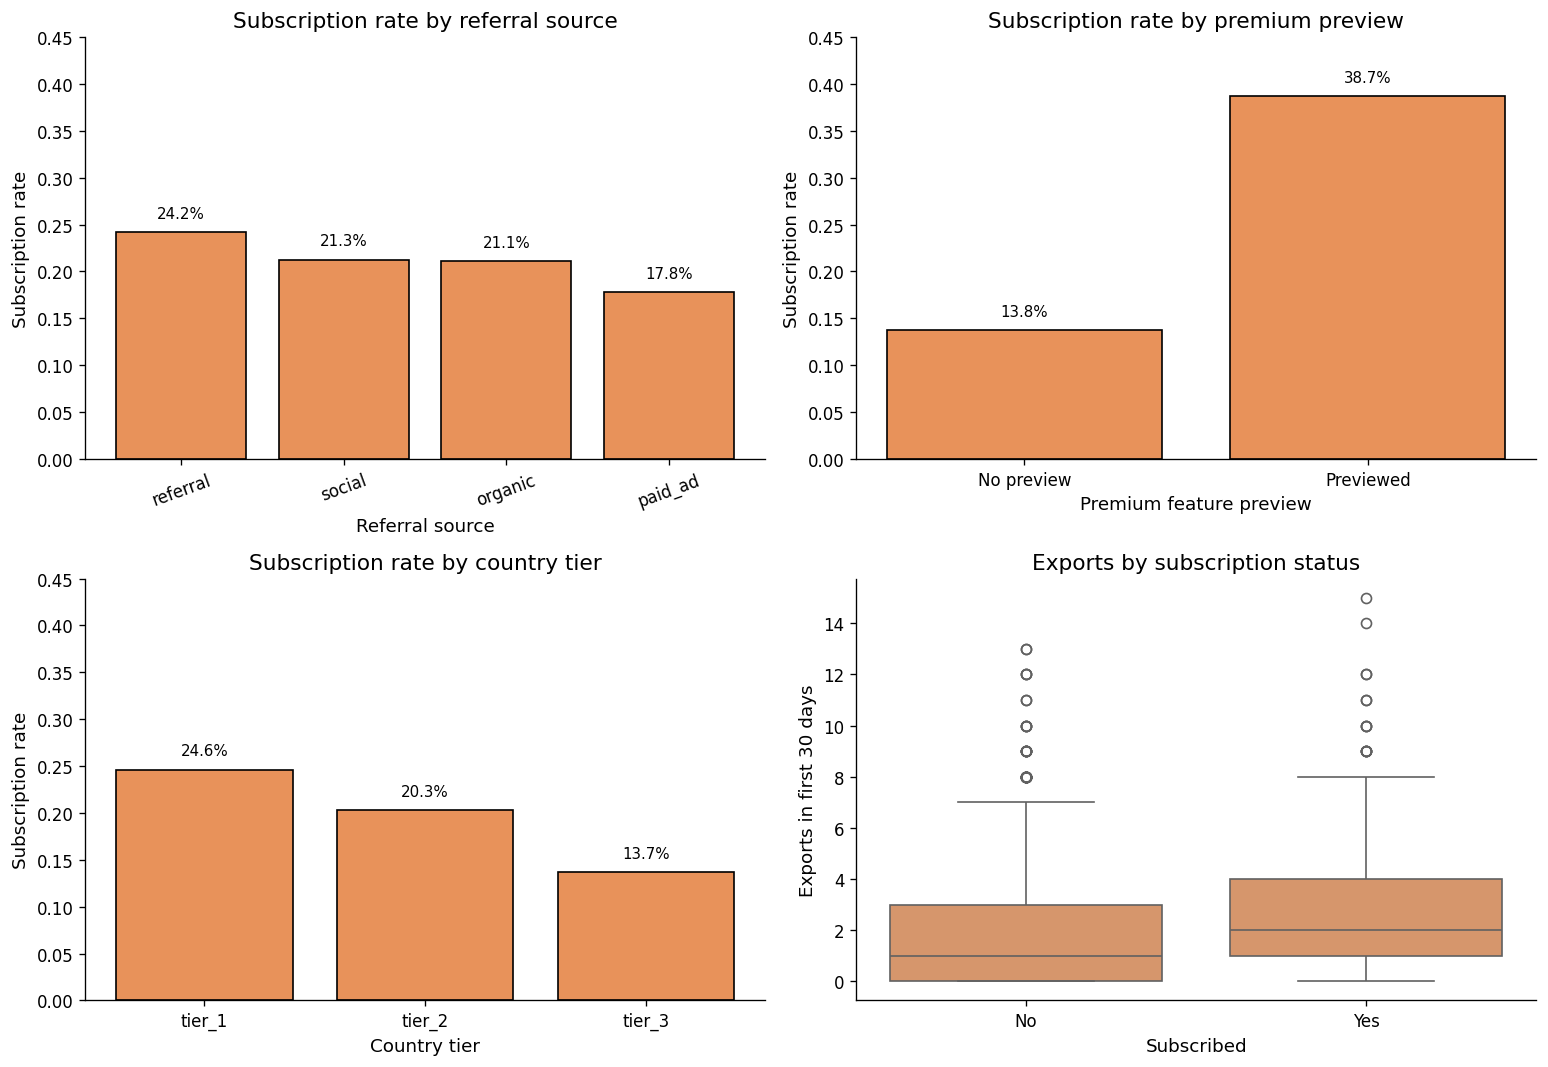

In [21]:
# Visualize subscription relationships for more than three features.
# I use simple bar charts and boxplots because they match the EDA style from the lectures.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Subscription rate by referral source
sub_by_ref = df_sub.groupby('referral_source')['subscribed'].mean().sort_values(ascending=False)
axes[0, 0].bar(sub_by_ref.index, sub_by_ref.values, color=ACCENT, edgecolor='black')
axes[0, 0].set_title('Subscription rate by referral source')
axes[0, 0].set_xlabel('Referral source')
axes[0, 0].set_ylabel('Subscription rate')
axes[0, 0].set_ylim(0, 0.45)
axes[0, 0].tick_params(axis='x', rotation=20)
for i, value in enumerate(sub_by_ref.values):
    axes[0, 0].text(i, value + 0.015, f'{value:.1%}', ha='center', fontsize=9)

# 2. Subscription rate by premium feature preview
sub_by_preview = df_sub.groupby('used_premium_feature_preview')['subscribed'].mean()
preview_labels = ['No preview', 'Previewed']
axes[0, 1].bar(preview_labels, sub_by_preview.values, color=ACCENT, edgecolor='black')
axes[0, 1].set_title('Subscription rate by premium preview')
axes[0, 1].set_xlabel('Premium feature preview')
axes[0, 1].set_ylabel('Subscription rate')
axes[0, 1].set_ylim(0, 0.45)
for i, value in enumerate(sub_by_preview.values):
    axes[0, 1].text(i, value + 0.015, f'{value:.1%}', ha='center', fontsize=9)

# 3. Subscription rate by country tier
sub_by_tier = df_sub.groupby('country_tier')['subscribed'].mean().sort_index()
axes[1, 0].bar(sub_by_tier.index, sub_by_tier.values, color=ACCENT, edgecolor='black')
axes[1, 0].set_title('Subscription rate by country tier')
axes[1, 0].set_xlabel('Country tier')
axes[1, 0].set_ylabel('Subscription rate')
axes[1, 0].set_ylim(0, 0.45)
for i, value in enumerate(sub_by_tier.values):
    axes[1, 0].text(i, value + 0.015, f'{value:.1%}', ha='center', fontsize=9)

# 4. Exports by subscription status
sns.boxplot(data=df_sub, x='subscribed', y='exports_30d', ax=axes[1, 1], color=ACCENT)
axes[1, 1].set_title('Exports by subscription status')
axes[1, 1].set_xlabel('Subscribed')
axes[1, 1].set_ylabel('Exports in first 30 days')
axes[1, 1].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

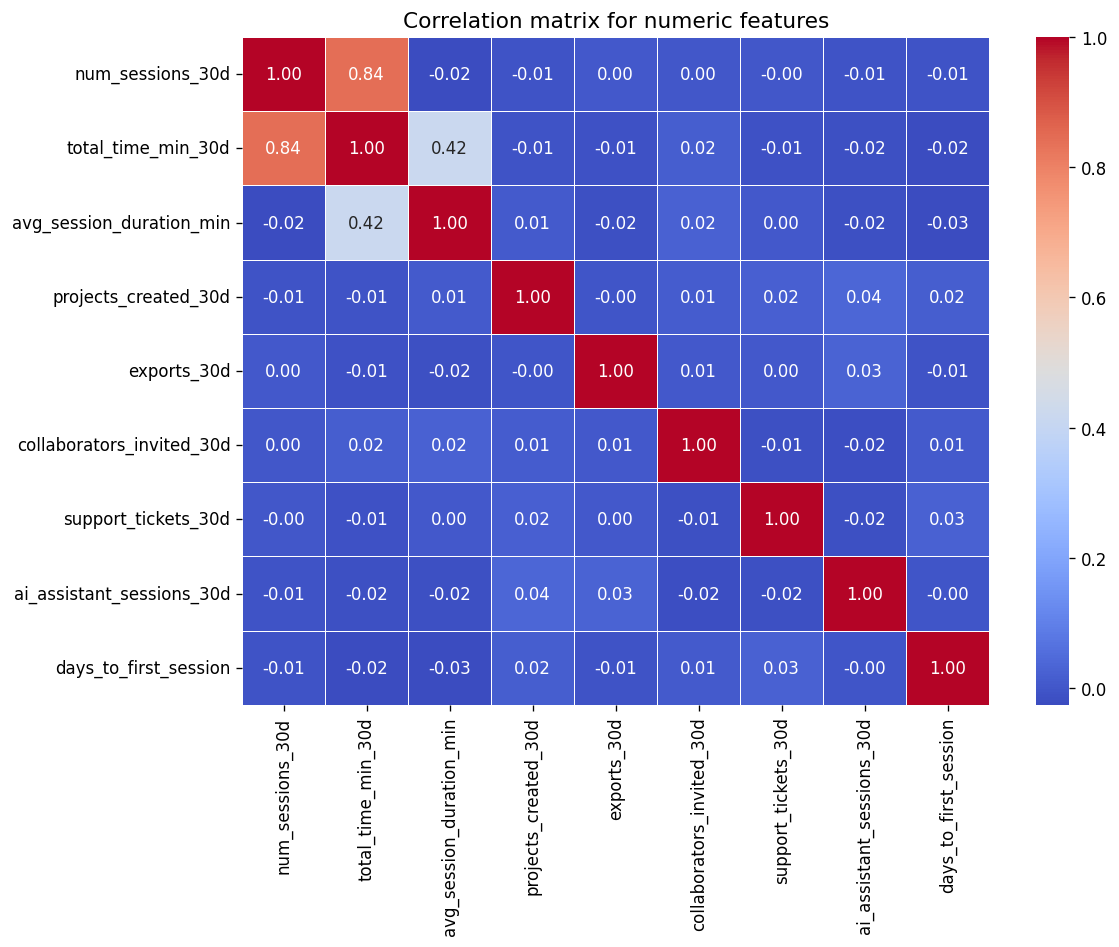

Strongest absolute correlations:
total_time_min_30d         num_sessions_30d             0.843
num_sessions_30d           total_time_min_30d           0.843
avg_session_duration_min   total_time_min_30d           0.417
total_time_min_30d         avg_session_duration_min     0.417
ai_assistant_sessions_30d  projects_created_30d         0.036
projects_created_30d       ai_assistant_sessions_30d    0.036
exports_30d                ai_assistant_sessions_30d    0.027
ai_assistant_sessions_30d  exports_30d                  0.027
dtype: float64


In [22]:
# Correlation matrix for numeric behavioral features.
# I include total_time_min_30d here for EDA so I can see its correlation with sessions,
# even though I did not include total_time_min_30d in the final model.

eda_numeric = [
    'num_sessions_30d',
    'total_time_min_30d',
    'avg_session_duration_min',
    'projects_created_30d',
    'exports_30d',
    'collaborators_invited_30d',
    'support_tickets_30d',
    'ai_assistant_sessions_30d',
    'days_to_first_session'
]

corr = df_sub[eda_numeric].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4, ax=ax)
ax.set_title('Correlation matrix for numeric features')
plt.tight_layout()
plt.show()

# Print the strongest correlations, excluding a variable with itself.
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1]
print('Strongest absolute correlations:')
print(pairs.head(8).round(3))

In [23]:
# This table gives a quick numeric summary of how selected features differ by subscription status.

summary_by_sub = (
    df_sub
    .groupby('subscribed')[eda_numeric + ['used_premium_feature_preview']]
    .agg(['mean', 'median'])
    .round(2)
)
display(summary_by_sub)

# Simple correlations with the binary outcome are not a full model,
# but they are helpful for EDA.
corr_cols = eda_numeric + ['used_premium_feature_preview', 'country_tier_enc', 'subscribed']
outcome_corr = (
    df_sub[corr_cols]
    .corr()['subscribed']
    .drop('subscribed')
    .sort_values(key=abs, ascending=False)
)

print('Correlations with subscribed:')
print(outcome_corr.round(3))

num_sessions_30d        total_time_min_30d         \
                       mean median               mean median   
subscribed                                                     
0                      9.15    8.0             211.83  182.0   
1                      9.63    9.0             232.67  202.0   

           avg_session_duration_min        projects_created_30d         \
                               mean median                 mean median   
subscribed                                                               
0                             23.18  23.00                 2.43    2.0   
1                             24.61  24.75                 2.43    2.0   

           exports_30d        collaborators_invited_30d         \
                  mean median                      mean median   
subscribed                                                       
0                 1.84    1.0                      1.80    1.0   
1                 2.66    2.0                      2.09    1.0   

           support_tickets_30d        ai_assistant_sessions_30d         \
                          mean median                      mean median   
subscribed                                                               
0                         0.65    0.0                      3.61    3.0   
1                         0.79    0.0                      3.76    3.0   

           days_to_first_session        used_premium_feature_preview         
                            mean median                         mean median  
subscribed                                                                   
0                           4.14    2.0                         0.22    0.0  
1                           2.72    2.0                         0.53    1.0

Correlations with subscribed:
used_premium_feature_preview    0.276
exports_30d                     0.163
days_to_first_session          -0.115
country_tier_enc               -0.102
avg_session_duration_min        0.072
total_time_min_30d              0.061
collaborators_invited_30d       0.056
support_tickets_30d             0.055
num_sessions_30d                0.038
ai_assistant_sessions_30d       0.020
projects_created_30d           -0.000
Name: subscribed, dtype: float64


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*

**My interpretation:**

The overall subscription rate is about `20.8%`, so the dataset is imbalanced because most users did not subscribe. The strongest EDA association is `used_premium_feature_preview`: users who previewed a premium feature subscribed at a much higher rate than users who did not. `exports_30d` also appears important because subscribers tend to export more, which makes sense because exporting means the user is producing work that may need to be saved, shared, or used outside the app. `days_to_first_session` appears negatively associated with subscription, meaning users who wait longer before their first session are less likely to subscribe. One counterintuitive pattern is that `support_tickets_30d` is positively related to subscription; I interpret this as a possible sign that serious users contact support because they are trying to complete real work, not because they are simply unhappy. The main correlation concern is that `total_time_min_30d` and `num_sessions_30d` are strongly correlated (`r ≈ 0.84`), so I did not include total time in the final model together with session count and average duration because it would make the model harder to interpret.

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.
No train/test split — the goal is to interpret coefficients, not evaluate prediction.

In [24]:
# Inferential logistic regression with statsmodels.
# This model uses the full dataset because the goal is coefficient interpretation.

X_const_sub = sm.add_constant(X_sub).astype(float)
model_logit = sm.Logit(y_sub, X_const_sub).fit(maxiter=200)
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.440669
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2983
Method:                           MLE   Df Model:                           16
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.1389
Time:                        03:15:40   Log-Likelihood:                -1322.0
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 1.039e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.3413      0.259     -9.036      0.000

In [25]:
# Convert logit coefficients into odds ratios.
# This follows the classification lecture: exp(beta) gives the multiplicative change in odds.

odds_ratios = np.exp(model_logit.params)
conf_int = np.exp(model_logit.conf_int())
conf_int.columns = ['OR_lower_95', 'OR_upper_95']

or_table = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    '95% CI Lower': conf_int['OR_lower_95'],
    '95% CI Upper': conf_int['OR_upper_95'],
    'p-value': model_logit.pvalues
})

significant_or = (
    or_table
    .drop(index='const')
    .query('`p-value` < 0.05')
    .sort_values('Odds Ratio', ascending=False)
)

print('Significant predictors (p < 0.05):')
display(significant_or.round(4))

Significant predictors (p < 0.05):


,Odds Ratio,95% CI Lower,95% CI Upper,p-value
used_premium_feature_preview,4.3394,3.5687,5.2766,0.0000
exports_30d,1.2146,1.1636,1.2677,0.0000
support_tickets_30d,1.1692,1.0746,1.2722,0.0003
collaborators_invited_30d,1.0629,1.0175,1.1103,0.0061
avg_session_duration_min,1.0236,1.0116,1.0357,0.0001
days_to_first_session,0.9119,0.8877,0.9368,0.0000
country_tier_enc,0.7007,0.6164,0.7965,0.0000


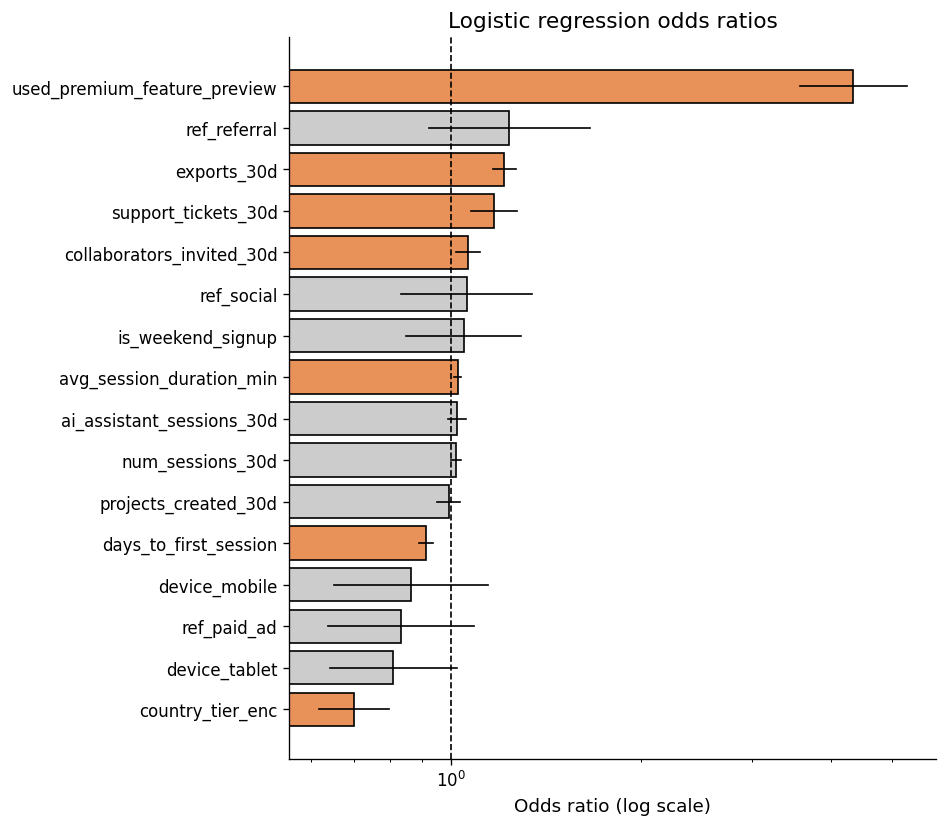

In [26]:
# Visualize odds ratios. The vertical line at 1 means no change in odds.

or_all = or_table.drop(index='const').sort_values('Odds Ratio')

fig, ax = plt.subplots(figsize=(8, 7))
colors = [ACCENT if p < 0.05 else '#cccccc' for p in or_all['p-value']]
ax.barh(or_all.index, or_all['Odds Ratio'], color=colors, edgecolor='black')

# Confidence interval lines
for i, (_, row) in enumerate(or_all.iterrows()):
    ax.plot([row['95% CI Lower'], row['95% CI Upper']], [i, i], color='black', linewidth=1)

ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio (log scale)')
ax.set_title('Logistic regression odds ratios')
plt.tight_layout()
plt.show()

**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*

**My results paragraph:**

The strongest predictor of subscription was `used_premium_feature_preview`. Holding the other variables constant, users who previewed a premium feature had about `4.34` times the odds of subscribing compared with users who did not preview one. `exports_30d` was also significant: each additional export was associated with about `1.21` times the odds of subscription, which suggests that users who produce downloadable or shareable work are more likely to see value in paying. `days_to_first_session` had an odds ratio of about `0.91`, meaning each extra day of delay before the first session reduced the odds of subscription by about 9%. `country_tier_enc` was also significant with an odds ratio below 1, suggesting that users in higher-numbered country tiers had lower odds of subscribing after controlling for behavior. A nuanced finding is that `support_tickets_30d` was positive and significant; at first this seems surprising because support problems sound negative, but it may mean that serious users submit tickets because they are actively trying to use the product for real work. `ai_assistant_sessions_30d` was not significant after controlling for other variables, so in this model AI usage alone appears less predictive than clearer purchase-intent signals such as premium preview and exports.

### B4 — Logistic Regression with sklearn (Predictive)

In [27]:
# Train/test split for prediction. Stratify keeps the positive subscription rate similar
# in both training and test data, which matters because the classes are imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    X_sub,
    y_sub,
    test_size=0.2,
    random_state=42,
    stratify=y_sub
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train shape: (2400, 16)
Test shape:  (600, 16)
Train positive rate: 0.208
Test positive rate:  0.208


In [28]:
# Fit sklearn LogisticRegression.
# I standardize the features because logistic regression is easier to optimize when features are on similar scales.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_lr.fit(X_train_scaled, y_train)

y_pred_lr = clf_lr.predict(X_test_scaled)
y_prob_lr = clf_lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic regression model fitted.')

Logistic regression model fitted.


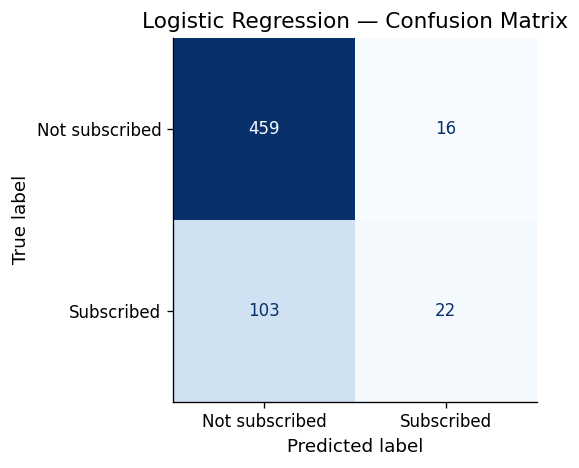

TN: 459 | FP: 16 | FN: 103 | TP: 22


In [29]:
# Confusion matrix for logistic regression.

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not subscribed', 'Subscribed']
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
print(f"TN: {tn_lr} | FP: {fp_lr} | FN: {fn_lr} | TP: {tp_lr}")

In [30]:
# Classification metrics and ROC-AUC.

print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed'], zero_division=0))
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC: {auc_lr:.4f}")

# Save report dictionary for Part C comparison.
lr_report = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)

                precision    recall  f1-score   support

Not subscribed       0.82      0.97      0.89       475
    Subscribed       0.58      0.18      0.27       125

      accuracy                           0.80       600
     macro avg       0.70      0.57      0.58       600
  weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7373


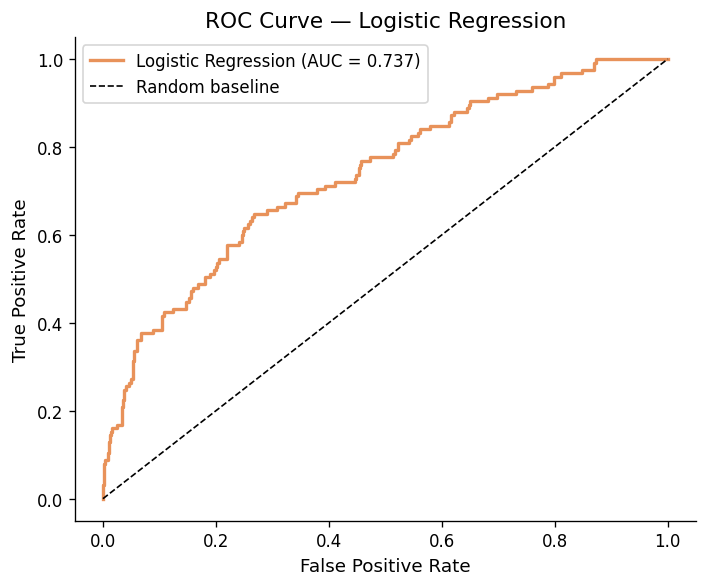

In [31]:
# ROC curve for logistic regression.

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, linewidth=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*

**My interpretation:**

Because only about `21%` of users subscribed, accuracy is not the most informative metric. A model can look accurate by mostly predicting the majority class, which is "not subscribed," so I focus more on class-1 recall, class-1 F1, and ROC-AUC. The logistic regression model had an ROC-AUC of about `0.737`, which means it has a moderate ability to rank likely subscribers above unlikely subscribers. The confusion matrix shows `459` true negatives, `16` false positives, `103` false negatives, and `22` true positives. This means the model missed `103` users who actually subscribed, which is a major limitation at the default `0.5` threshold. From Phigma's business perspective, false negatives matter because these are users with real conversion potential who might not receive targeted onboarding, sales messaging, or premium-feature nudges. If Phigma cares more about finding potential subscribers than avoiding extra outreach, I would consider lowering the decision threshold to improve recall.

---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`
**Same train/test split as B4.** Do not re-split.

### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.

**✏️ Your chosen model:** `Gaussian Naive Bayes`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*

**My explanation:**

I chose Gaussian Naive Bayes because it connects directly to the probability, normal distribution, and Bayes' theorem ideas from the lectures. The model learns from the training data by estimating the mean and variance of each numeric feature separately within each class, then it uses Bayes' theorem to estimate which class is more likely for a new user. Under the Gaussian version, the model assumes each feature follows a bell-shaped distribution within each class, and it chooses the class with the highest posterior probability. It is called "naive" because it assumes features are conditionally independent within each class, which is a strong simplification because user behavior features can be related to each other. This is structurally different from logistic regression because logistic regression learns one linear log-odds equation, while Naive Bayes builds separate class-conditional probability estimates. It might perform differently here because the dataset has clear probability signals, such as premium preview and exports, but the independence assumption may be imperfect because engagement features can still move together.

### C2 — Fit and Evaluate

In [32]:
# Fit Gaussian Naive Bayes using the same train/test split from B4.
# I use the scaled matrices already created for logistic regression.

clf_nb = GaussianNB()
clf_nb.fit(X_train_scaled, y_train)

y_pred_nb = clf_nb.predict(X_test_scaled)
y_prob_nb = clf_nb.predict_proba(X_test_scaled)[:, 1]

print('Gaussian Naive Bayes model fitted.')

Gaussian Naive Bayes model fitted.


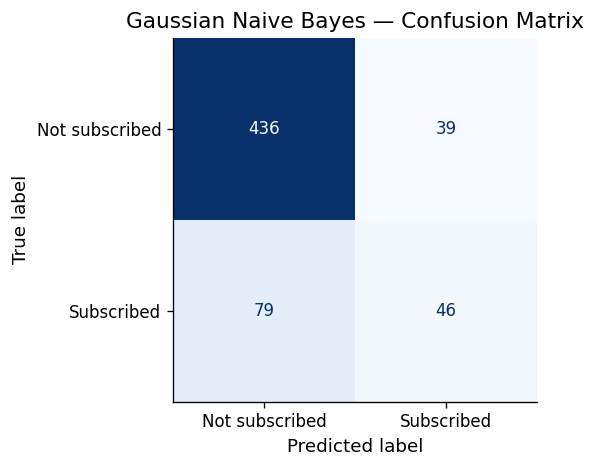

TN: 436 | FP: 39 | FN: 79 | TP: 46


In [33]:
# Confusion matrix for Gaussian Naive Bayes.

cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=['Not subscribed', 'Subscribed']
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Gaussian Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()

tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()
print(f"TN: {tn_nb} | FP: {fp_nb} | FN: {fn_nb} | TP: {tp_nb}")

In [34]:
# Classification report and ROC-AUC for Gaussian Naive Bayes.

print(classification_report(y_test, y_pred_nb, target_names=['Not subscribed', 'Subscribed'], zero_division=0))
auc_nb = roc_auc_score(y_test, y_prob_nb)
print(f"ROC-AUC: {auc_nb:.4f}")

nb_report = classification_report(y_test, y_pred_nb, output_dict=True, zero_division=0)

                precision    recall  f1-score   support

Not subscribed       0.85      0.92      0.88       475
    Subscribed       0.54      0.37      0.44       125

      accuracy                           0.80       600
     macro avg       0.69      0.64      0.66       600
  weighted avg       0.78      0.80      0.79       600

ROC-AUC: 0.7478


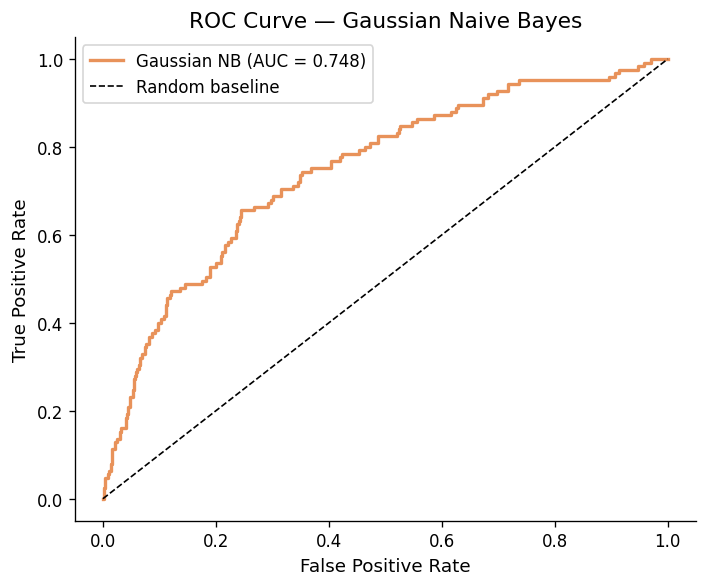

In [35]:
# ROC curve for Gaussian Naive Bayes.

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_nb, tpr_nb, color=ACCENT, linewidth=2, label=f'Gaussian NB (AUC = {auc_nb:.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Gaussian Naive Bayes')
ax.legend()
plt.tight_layout()
plt.show()

### C3 — Model Comparison

In [36]:
# Summary comparison table for the positive class (subscribed = 1).

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes'],
    'ROC-AUC': [auc_lr, auc_nb],
    'Precision (class 1)': [lr_report['1']['precision'], nb_report['1']['precision']],
    'Recall (class 1)': [lr_report['1']['recall'], nb_report['1']['recall']],
    'F1 (class 1)': [lr_report['1']['f1-score'], nb_report['1']['f1-score']],
    'False negatives': [fn_lr, fn_nb],
    'False positives': [fp_lr, fp_nb]
}).set_index('Model')

comparison.round(4)

,ROC-AUC,Precision (class 1),Recall (class 1),F1 (class 1),False negatives,False positives
Model,,,,,,
Logistic Regression,0.7373,0.5789,0.176,0.2699,103,16
Gaussian Naive Bayes,0.7478,0.5412,0.368,0.4381,79,39


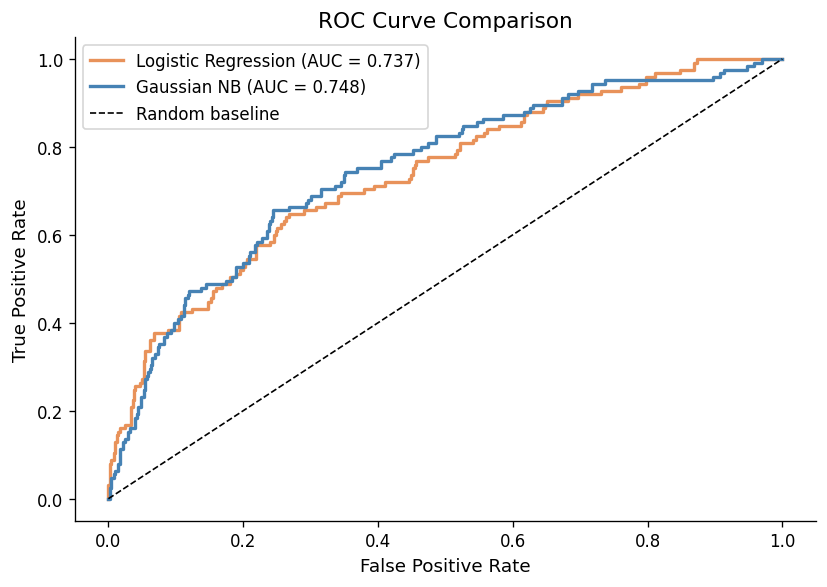

In [37]:
# Plot both ROC curves on the same axes.

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color=ACCENT, linewidth=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_nb, tpr_nb, color='steelblue', linewidth=2, label=f'Gaussian NB (AUC = {auc_nb:.3f})')
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*

**My comparison paragraph:**

Gaussian Naive Bayes performed slightly better than logistic regression on ROC-AUC and clearly better on class-1 recall and class-1 F1. Logistic regression had an ROC-AUC of about `0.737`, class-1 recall of about `0.176`, and class-1 F1 of about `0.270`. Gaussian Naive Bayes had an ROC-AUC of about `0.748`, class-1 recall of about `0.368`, and class-1 F1 of about `0.438`. The practical difference is that Naive Bayes caught more actual subscribers: logistic regression missed `103` subscribers, while Naive Bayes missed `79`. However, Naive Bayes also produced more false positives (`39` compared with `16`), so the improvement comes with a tradeoff. I think this happened because the default logistic regression classifier was conservative in an imbalanced dataset, while Naive Bayes was more willing to classify users as subscribers when several probability signals pointed toward the positive class. If Phigma wants to avoid bothering users who are unlikely to subscribe, logistic regression is safer; if Phigma wants to find more possible subscribers for outreach, Gaussian Naive Bayes is more useful in this test.

### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*

In [38]:
# Bonus tuning for Gaussian Naive Bayes.
# GaussianNB has one main smoothing hyperparameter, so I test several values.

param_grid = {
    'var_smoothing': np.logspace(-12, -6, 7)
}

search = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
search.fit(X_train_scaled, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC:     {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test_scaled)
y_prob_tuned = search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned test AUC:   {auc_tuned:.4f}")
print(f"Default test AUC: {auc_nb:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['Not subscribed', 'Subscribed'], zero_division=0))

if abs(auc_tuned - auc_nb) < 0.005:
    print('Tuning did not meaningfully change performance; the default GaussianNB model was already close to the tuned result.')
else:
    print('Tuning changed performance enough to be noticeable on the test set.')

Best parameters: {'var_smoothing': np.float64(1e-12)}
Best CV AUC:     0.7150
Tuned test AUC:   0.7478
Default test AUC: 0.7478
                precision    recall  f1-score   support

Not subscribed       0.85      0.92      0.88       475
    Subscribed       0.54      0.37      0.44       125

      accuracy                           0.80       600
     macro avg       0.69      0.64      0.66       600
  weighted avg       0.78      0.80      0.79       600

Tuning did not meaningfully change performance; the default GaussianNB model was already close to the tuned result.


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`